In [1]:
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import sklearn.model_selection
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:

def display_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)

    plt.rcParams["figure.figsize"] = [12,9]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()


In [ ]:
!pip install obspy

In [ ]:
import tarfile

with tarfile.open('data_v2.tar.xz') as f:
    f.extractall('.')

In [ ]:
import tarfile

with tarfile.open('data_v2.tar.xz') as f:
    f.extractall('.')

In [ ]:
import tarfile

with tarfile.open('dataset4k.tar.xz') as f:
    f.extractall('.')

In [15]:
from obspy.core import read
import obspy
import os
import numpy as np


data_path = 'dataset4k'
class0_data_path = os.path.join(data_path, 'class0')
class1_data_path = os.path.join(data_path, 'class1')
class2_data_path = os.path.join(data_path, 'class2')
class3_data_path = os.path.join(data_path, 'class3')
class4_data_path = os.path.join(data_path, 'class4')
class5_data_path = os.path.join(data_path, 'class5')
class6_data_path = os.path.join(data_path, 'class6')
class7_data_path = os.path.join(data_path, 'class7')
class8_data_path = os.path.join(data_path, 'class8')


size = 4000
X_train = np.array([])
X_test  = np.array([])
y_train = np.array([])
y_test  = np.array([])

def loadfile(file_data_path):
    if not os.path.isfile(file_data_path):
        return None
    data = np.array([])

    singlechannel = obspy.read(file_data_path)
    data = np.array(singlechannel[0].data)

    # print(data.shape)

    return data

def loadfolder(folder_data_path):
    result_data = np.array([])

    for data_file_name in os.listdir(folder_data_path):
        data_file_path = os.path.join(folder_data_path, data_file_name)
        data = loadfile(data_file_path)
        result_data = np.append(result_data, np.array(data))

    x = len(result_data) // size
    result_data = result_data.reshape((x, size))
    return result_data

def reload4k():
    global X_train, X_test, y_train, y_test

    class0_data = loadfolder(class0_data_path)
    print(class0_data.shape)

    class1_data = loadfolder(class1_data_path)
    print(class1_data.shape)

    class2_data = loadfolder(class2_data_path)
    print(class2_data.shape)

    class3_data = loadfolder(class3_data_path)
    print(class3_data.shape)

    class4_data = loadfolder(class4_data_path)
    print(class4_data.shape)

    class5_data = loadfolder(class5_data_path)
    print(class5_data.shape)

    class6_data = loadfolder(class6_data_path)
    print(class6_data.shape)

    class7_data = loadfolder(class7_data_path)
    print(class7_data.shape)

    class8_data = loadfolder(class8_data_path)
    print(class8_data.shape)



    # until = 250 // 5
    # data_01234 = np.concatenate((class0_data[:until], class1_data[:until], class2_data[:until * 2], class3_data[:until]), axis = 0)
    # label_01234 = np.zeros((data_01234.shape[0]))

    # label_01 = np.concatenate((class0_label, class1_label), axis = 0)

    data_0 = class0_data
    label_0 = np.zeros((data_0.shape[0]))


    data_5678 = np.concatenate((class5_data, class6_data, class7_data, class8_data), axis = 0)
    label_5678 = np.ones((data_5678.shape[0]))

    until = (len(class0_data) - len(data_5678)) // 16

    data_1234 = np.concatenate((class2_data[:until], class3_data[:until], class4_data[:until]), axis = 0)
    label_1234 = np.ones((data_1234.shape[0]))

    data_p = np.concatenate((data_1234, data_5678), axis = 0)
    label_p = np.concatenate((label_1234, label_5678), axis = 0)

    data_0 = data_0[:len(data_p)]
    label_0 = label_0[:len(label_p)]

    X = np.concatenate((data_0, data_p), axis = 0)
    Y = np.concatenate((label_0, label_p), axis = 0)

    print("============")
    print(data_0.shape)
    print(data_p.shape)
    print(data_1234.shape)
    print(data_5678.shape)
    print(X.shape)
    print(Y.shape)


    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.50, random_state=0)

    print("============")
    print(X_train.shape)
    print(X_test.shape)

    return X_train, X_test, y_train, y_test


reload4k()


(1064, 4000)
(544, 4000)
(398, 4000)
(306, 4000)
(169, 4000)
(119, 4000)
(65, 4000)
(42, 4000)
(23, 4000)
(399, 4000)
(399, 4000)
(150, 4000)
(249, 4000)
(798, 4000)
(798,)
(399, 4000)
(399, 4000)


(array([[ 8.22723985e-01,  3.11442757e+00,  5.24630690e+00, ...,
          7.82378006e+00,  6.23430443e+00,  4.49539900e+00],
        [ 4.70384903e+01,  4.53237686e+01,  4.13751144e+01, ...,
         -6.83741760e+01, -6.94132233e+01, -7.28373413e+01],
        [-4.97697639e+01, -1.20882673e+01,  2.79174671e+01, ...,
         -3.54588479e-01, -2.24535294e+01, -2.90257797e+01],
        ...,
        [ 1.31469088e+01,  2.18467464e+01,  2.51136475e+01, ...,
         -2.69865723e+01, -2.51779804e+01, -1.93760052e+01],
        [ 5.00795410e+02,  5.04175629e+02,  4.93030487e+02, ...,
         -4.60226105e+02, -4.93447662e+02, -4.90729431e+02],
        [ 2.56760826e+01,  6.12322197e+01,  9.50128174e+01, ...,
          8.91630478e+01,  9.84974670e+01,  1.02970589e+02]]),
 array([[-347.04327393, -244.96650696, -130.08248901, ...,  603.58966064,
          600.92675781,  578.22827148],
        [  21.74593163,   26.45435905,   30.14771271, ..., -137.49398804,
         -150.13658142, -155.72070312],
 

In [ ]:
from obspy.core import read
import obspy

data_path = 'data'

class1_data_path = os.path.join(data_path, 'class1')
class2_data_path = os.path.join(data_path, 'class2')
class3_data_path = os.path.join(data_path, 'class3')


fix_size = 32_000
X_train  = np.array([])
X_test  = np.array([])
y_train  = np.array([])
y_test = np.array([])

def load_file_data1(file_data_path):

    if not os.path.isfile(file_data_path):
        return None

    data = np.array([])
    # with open(file_data_path, 'r') as data_file:
    #     data = np.loadtxt(data_file, delimiter=' ')

    singlechannel = obspy.read(file_data_path)
    data = np.array(singlechannel[0].data)


    if data.shape[0] > fix_size:
        data = data[:fix_size, :]
    else:
        x = fix_size // data.shape[0]
        for i in range(x):
            data = np.concatenate((data, data), axis=0)

    data = data[:fix_size]
    return data


def load_data1(folder_data_path):

    result_data = np.array([])
    for data_file_name in os.listdir(folder_data_path):

        data_file_path = os.path.join(folder_data_path, data_file_name)
        data = load_file_data1(data_file_path)
        result_data = np.append(result_data, data)

    x = len(result_data) // fix_size
    result_data = result_data.reshape((x, fix_size))
    return result_data

def reload1():
  global X_train, X_test, y_train, y_test

  class1_data = load_data1(class1_data_path)
  class1_label = np.ones((class1_data.shape[0]))

  # class3_data = load_data1(class3_data_path)
  # class3_label = np.ones((class3_data.shape[0]))

  class2_data = load_data1(class2_data_path)
  class2_data = np.split(class2_data,[63])[0]
  class2_label = np.zeros((class2_data.shape[0]))


  print(class1_data.shape)
  print(class2_data.shape)
  # print(class3_data.shape)

  data = np.concatenate((class1_data, class2_data), axis=0)
  print(data.shape)
  label = np.concatenate((class1_label, class2_label), axis=0)
  print(label.shape)


  # data = np.concatenate((class1_data, class2_data, class3_data), axis=0)
  # print(data.shape)
  # label = np.concatenate((class1_label, class2_label, class3_label), axis=0)
  # print(label.shape)

  X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(data, label, test_size=0.20, random_state=0)

  print(X_train.shape)
  print(X_test.shape)

  return X_train, X_test, y_train, y_test

reload1()


In [ ]:
from obspy.core import read
import obspy

data_path = './data_v2'

class1_data_path = os.path.join(data_path, 'class1')
class2_data_path = os.path.join(data_path, 'class2')
class3_data_path = os.path.join(data_path, 'class3/class1')


fix_size = 32_000
X_train  = np.array([])
X_test  = np.array([])
y_train  = np.array([])
y_test = np.array([])

def load_file_data2(file_data_path):

    if not os.path.isfile(file_data_path):
        return None

    data = np.array([])
    # with open(file_data_path, 'r') as data_file:
    #     data = np.loadtxt(data_file, delimiter=' ')

    singlechannel = obspy.read(file_data_path)
    data = np.array(singlechannel[0].data)


    if data.shape[0] > fix_size:
        data = data[:fix_size, :]
    else:
        x = fix_size // data.shape[0]
        for i in range(x):
            data = np.concatenate((data, data), axis=0)

    data = data[:fix_size]
    return data


def load_data2(folder_data_path):

    result_data = np.array([])
    for data_file_name in os.listdir(folder_data_path):

        data_file_path = os.path.join(folder_data_path, data_file_name)
        data = load_file_data2(data_file_path)
        result_data = np.append(result_data, data)

    x = len(result_data) // fix_size
    result_data = result_data.reshape((x, fix_size))
    return result_data

def reload2():
  global X_train, X_test, y_train, y_test

  class1_data = load_data2(class1_data_path)
  class1_label = np.ones((class1_data.shape[0]))

  class3_data = load_data2(class3_data_path)
  class3_label = np.ones((class3_data.shape[0]))

  class2_data = load_data2(class2_data_path)
  class2_data = np.split(class2_data,[120])[0]
  class2_label = np.zeros((class2_data.shape[0]))


  print(class1_data.shape)
  print(class2_data.shape)
  print(class3_data.shape)

  data = np.concatenate((class1_data, class2_data, class3_data), axis=0)
  print(data.shape)
  label = np.concatenate((class1_label, class2_label, class3_label), axis=0)
  print(label.shape)

  X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(data, label, test_size=0.30, random_state=0)

  print(X_train.shape)
  print(X_test.shape)

  return X_train, X_test, y_train, y_test

reload2()


In [ ]:
import tensorflow as tf

# Load the SavedModel
model = tf.keras.models.load_model('./drive/MyDrive/4k_v2')


In [ ]:

# Path: model.ipynb
from sklearn import svm
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = reload4k()

clf = svm.SVC()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['class2', 'class1'], columns=['class2', 'class1'])
plt.figure(figsize=(5.5,4))
sns.heatmap(cm_df, annot=True)
plt.title('SVM \nAccuracy:{0:.3f}'.format(accuracy_score(y_test, y_pred)))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


In [ ]:
# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = reload4k()

rfc = RandomForestClassifier(max_depth=5, random_state=2)
rfc.fit(X_train, y_train)

# draw confusion matrix
y_pred = rfc.predict(X_test)

print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['class2', 'class1'], columns=['class2', 'class1'])
plt.figure(figsize=(5.5,4))
sns.heatmap(cm_df, annot=True)
plt.title('Random Forest \nAccuracy:{0:.3f}'.format(accuracy_score(y_test, y_pred)))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



In [ ]:
from obspy import Trace

file_path = "./data/class1/06_02_22KULA.BHZ.SAC"

# file_path = "./data/class1/01_04_22SIMA.BHZ.SAC"

divider = 32
data = np.array([])
# with open(file_data_path, 'r') as data_file:
#     data = np.loadtxt(data_file, delimiter=' ')

singlechannel = obspy.read(file_path)
data = np.array(singlechannel[0].data)
mean = np.mean(data)

dif_size = 32_000 - len(data)
mean_arr = np.zeros(dif_size) + mean

data = np.concatenate((data, mean_arr))

tr = Trace(data=data)
tr.plot()

size = len(data)

split_data = np.split(data, divider)
print(split_data[0].shape)
print(type(split_data))

data = data.reshape(1, -1)
pred = rfc.predict(data)

p_arr_preds = []
for i in range(divider):
  temp = split_data[i]

  split_data[i] = np.zeros(size // divider) + mean

  listt = []
  for l in split_data:
    listt.append(l)

  pred_data = np.array(listt)
  # print(pred_data)

  pred_data = pred_data.reshape(1, -1)
  pred = rfc.predict(pred_data)
  p_arr_preds.append(pred[0])
  # print(pred)

  tr = Trace(data=pred_data[0])
  # tr.plot()

  split_data[i] = temp

print(p_arr_preds)

first_zero_index = -1
last_zero_index = -1

for i,f in enumerate(p_arr_preds):
  if f == 0:
    first_zero_index = i
    break

for i,l in enumerate(p_arr_preds):
  if l == 0:
    last_zero_index = i

print(first_zero_index)
print(last_zero_index)

for i, val in enumerate(p_arr_preds):
  if val == 1:
    split_data[i] = np.zeros(size // divider) + mean


result_arr = []
for l in split_data:
  result_arr.append(l)

tr = Trace(data = np.array(result_arr).flatten())
tr.plot()

In [ ]:
"""




"""

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = reload4k()

neigh = KNeighborsClassifier(n_neighbors=3)

# decrease dimension
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1]))

neigh.fit(X_train, y_train)

# draw confusion matrix
y_pred = neigh.predict(X_test)
print(accuracy_score(y_test, y_pred))

# display_confusion_matrix(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['class2', 'class1'], columns=['class2', 'class1'])
plt.figure(figsize=(5.5,4))
sns.heatmap(cm_df, annot=True)
plt.title('KNN \nAccuracy:{0:.3f}'.format(accuracy_score(y_test, y_pred)))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


In [ ]:
"""




"""

In [ ]:
X_train.size

In [ ]:
print(X_train.shape)
print(X_test.shape)


In [ ]:
# Use CNN to train model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = reload1()

# Path: model.ipynb
divider = 4

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

print(X_train.shape)
print(X_test.shape)

model = models.Sequential(
    [
        layers.Conv1D(1024, 3, activation="relu", input_shape=(X_train.shape[1], X_test.shape[2])),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(2, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=300, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
# plt.legend(loc='lower right')
plt.show()



In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
model.summary()

In [21]:
model.save("./models/model4k_0_2-8_97")

2023-06-15 21:29:19.549606: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,1997,32]
	 [[{{node inputs}}]]
2023-06-15 21:29:19.818851: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,1997,32]
	 [[{{node inputs}}]]


INFO:tensorflow:Assets written to: ./models/model4k_0_2-8_97/assets


INFO:tensorflow:Assets written to: ./models/model4k_0_2-8_97/assets


(1064, 4000)
(544, 4000)
(398, 4000)
(306, 4000)
(169, 4000)
(119, 4000)
(65, 4000)
(42, 4000)
(23, 4000)
(399, 4000)
(399, 4000)
(150, 4000)
(249, 4000)
(798, 4000)
(798,)
(399, 4000)
(399, 4000)
Epoch 1/50
13/13 [==============================] - 2s 102ms/step - loss: 1.5740 - accuracy: 0.4737 - val_loss: 0.5403 - val_accuracy: 0.4962
Epoch 2/50
13/13 [==============================] - 1s 93ms/step - loss: 0.4856 - accuracy: 0.5163 - val_loss: 0.4355 - val_accuracy: 0.5890
Epoch 3/50
13/13 [==============================] - 1s 94ms/step - loss: 0.4227 - accuracy: 0.6617 - val_loss: 0.4251 - val_accuracy: 0.6366
Epoch 4/50
13/13 [==============================] - 1s 97ms/step - loss: 0.4062 - accuracy: 0.6341 - val_loss: 0.4212 - val_accuracy: 0.6316
Epoch 5/50
13/13 [==============================] - 1s 97ms/step - loss: 0.3980 - accuracy: 0.6867 - val_loss: 0.4186 - val_accuracy: 0.7218
Epoch 6/50
13/13 [==============================] - 1s 96ms/step - loss: 0.3893 - accuracy: 0.731

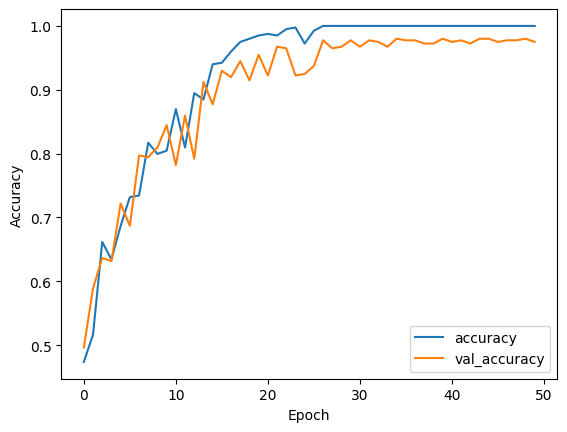

In [18]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

num_epochs = 50

X_train, X_test, y_train, y_test = reload4k()

model = models.Sequential(
    [
        layers.Conv1D(128, 3, activation="relu", input_shape=(X_train.shape[1], 1)),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.4),
        layers.MaxPooling1D(2),
        layers.Conv1D(4, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

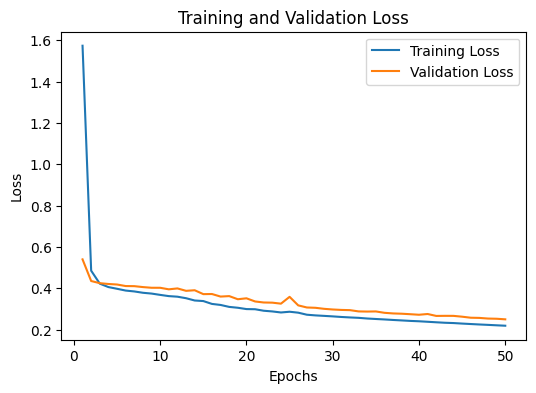

In [19]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(6, 4))
plt.plot(range(1, 50+1), train_loss, label='Training Loss')
plt.plot(range(1, 50+1), val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
for y_val in y_pred:
  print( "%.5f" % float(y_val), end = ", ")


(399, 4000)
13/13 [==============================] - 0s 30ms/step
0.974937343358396


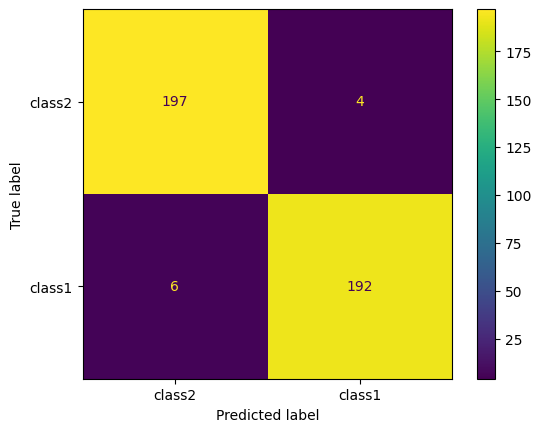

In [20]:
from sklearn.metrics import accuracy_score


print(X_test.shape)
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['class2', 'class1'])
disp.plot()

In [21]:
import tensorflow as tf

# Load the SavedModel
model = tf.keras.models.load_model('./models/model4k_0_2-8_97')


2023-06-16 00:27:49.449243: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-16 00:27:49.450751: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-06-16 00:27:49.480457: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-06-16 00:27:49.480870: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-16 00:27:50.029705: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [17]:
color_list = [
    (144, 238, 144),   # Light Green
    (133, 227, 133),
    (122, 217, 122),
    (111, 206, 111),
    (101, 196, 101),
    (90, 185, 90),
    (79, 175, 79),
    (69, 164, 69),
    (58, 154, 58),
    (47, 143, 47),
    (37, 133, 37),
    (26, 122, 26),
    (15, 112, 15),
    (5, 101, 5),
    (0, 91, 0),
    (0, 83, 0),
    (0, 76, 0),
    (0, 68, 0),
    (0, 61, 0),
    (0, 53, 0),
    (0, 46, 0),
    (0, 38, 0),
    (0, 31, 0),
    (0, 23, 0),
    (0, 16, 0),
    (0, 8, 0),
    (0, 0, 255),       # Blue
    (0, 0, 232),
    (0, 0, 209),
    (0, 0, 186),
    (0, 0, 163),
    (0, 0, 140),
    (0, 0, 117),
    (0, 0, 94),
    (0, 0, 71),
    (0, 0, 48),
    (0, 0, 25),
    (21, 21, 0),
    (42, 42, 0),
    (64, 64, 0),
    (85, 85, 0),
    (107, 107, 0),
    (128, 128, 0),
    (150, 150, 0),
    (171, 171, 0),
    (193, 193, 0),
    (214, 214, 0),
    (236, 236, 0),
    (255, 0, 0),       # Red
    (232, 0, 0),
    (209, 0, 0),
    (186, 0, 0),
    (163, 0, 0),
    (140, 0, 0),
    (117, 0, 0),
    (94, 0, 0),
    (71, 0, 0),
    (48, 0, 0),
    (25, 0, 0),
    (0, 0, 0)          # Dark Red
]


In [54]:
color_list = [
    (144, 238, 144),   # Light Green
    (60, 179, 113),
    (34, 139, 34),
    (0, 128, 0),       # Green
    (0, 0, 255),       # Blue
    (30, 144, 255),
    (0, 0, 128),       # Dark Blue
    (255, 0, 0),       # Red
    (165, 42, 42),
    (139, 0, 0)        # Dark Red
]


In [ ]:
color_list = [
    (0, 0, 255),      # Blue
    (0, 128, 0),      # Green
    (255, 255, 0),    # Yellow
    (255, 140, 0),    # Dark Orange
    (255, 0, 0)       # Red
]


(4000,)


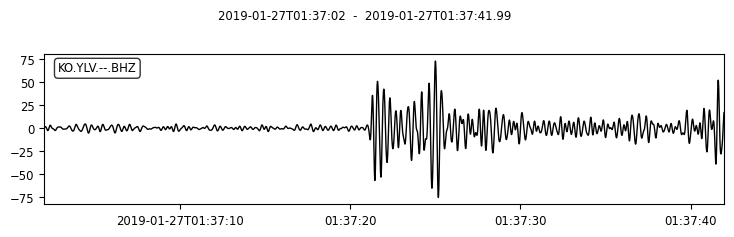

1000
(4000,)


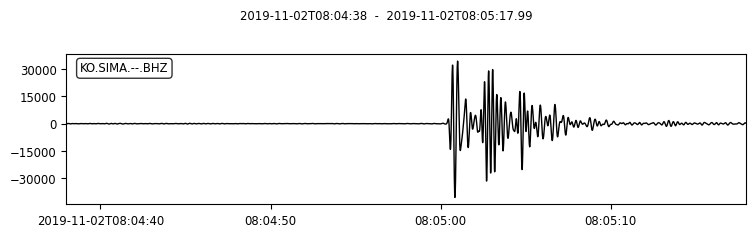

(1000,)


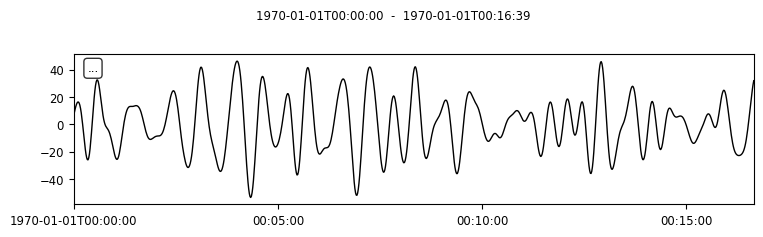

(1, 4000)
4000
0 1000


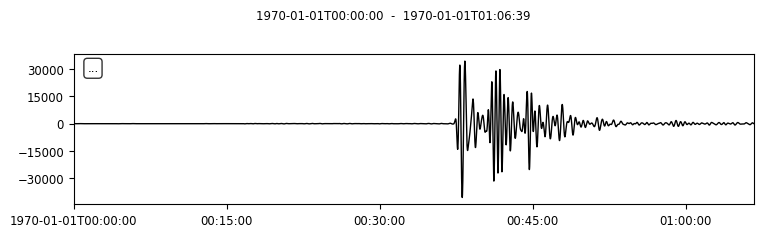

1/1 [==============================] - 0s 15ms/step
1.00000, 1000 2000


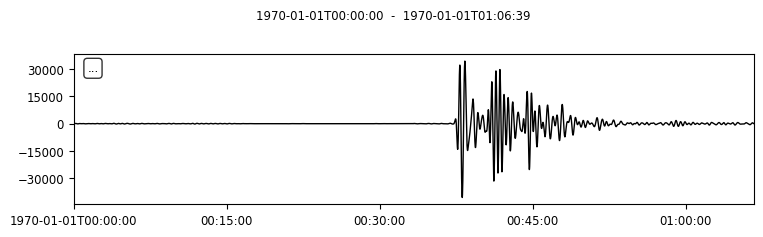

1/1 [==============================] - 0s 14ms/step
1.00000, 2000 3000


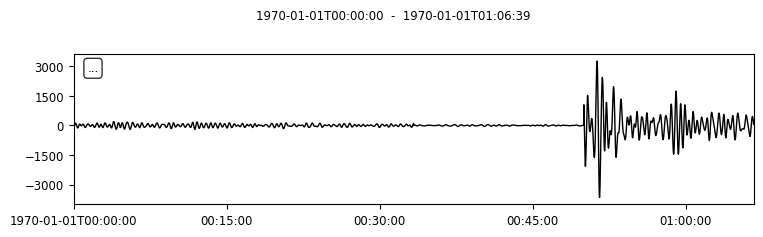

1/1 [==============================] - 0s 15ms/step
0.35554, 3000 4000


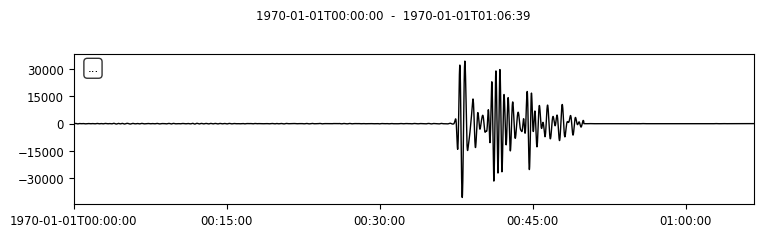

1/1 [==============================] - 0s 16ms/step
1.00000, 

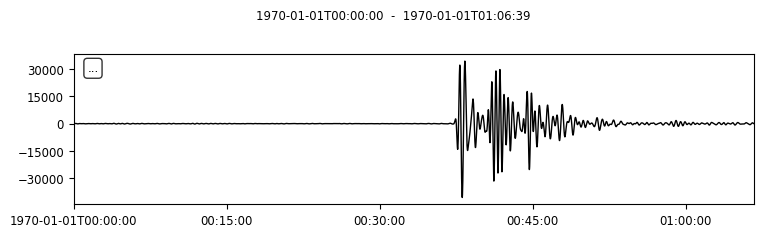

[1.0, 1.0, 0.3555371165275574, 1.0]


In [51]:
from obspy import read, Trace
import numpy as np

divide_number = 4

path0 = "./dataset4k/class0/201901_10_14_YLV.BHZ.SAC"
trace0 = read(path0)[0]
print(trace0.data.shape)
trace0.plot()

yummydata = np.array(trace0.data[:len(trace0.data) // divide_number] * 10)
print(len(yummydata))

path8 = "./dataset4k/class0/201901_0_5_YLV.BHZ.SAC"
path8 = "./dataset4k/class1/201901_14_29_KCTX.BHZ.SAC"
path8 = "./dataset4k/class2/201901_20_37_TVSB.BHZ.SAC"
path8 = "./dataset4k/class5/201903_14_0_SIMA.BHZ.SAC"
path8 = "./dataset4k/class7/201901_20_0_SIMA.BHZ.SAC"
path8 = "./dataset4k/class8/201911_3_1_SIMA.BHZ.SAC"

trace8 = read(path8)[0]
print(trace8.data.shape)
trace8.plot()

tmp = Trace(data = yummydata)
print(tmp.data.shape)
tmp.plot()


predict_data = trace8.data.reshape((1, len(trace8.data)))
print(predict_data.shape)
print(len(predict_data[0]))

# y_pred = model.predict(predict_data)
# for y_val in y_pred:
#   print( "%.5f" % float(y_val), end = ", ")

pred_list = []

for i in range(divide_number):
    start_index = i * (len(predict_data[0]) // divide_number)
    end_index = (i + 1) * (len(predict_data[0]) // divide_number)

    print(str(start_index) + " " + str(end_index))

    # Protect the original data by making a copy
    original_data = predict_data.copy()

    # Replace the section of predict_data with yummydata
    predict_data[0, start_index:end_index] = yummydata[:]

    pl = Trace(data = predict_data[0])
    pl.plot()

    # # Perform the prediction on the modified predict_data
    y_pred = model.predict(predict_data)
    for y_val in y_pred[0]:
        print("%.5f" % float(y_val), end=", ")
        pred_list.append(float(y_val))

    # # Restore the original data
    predict_data = original_data.copy()


trace = Trace(data = predict_data[0])
trace.plot()
trace.plot(outfile='trace_image.png')
print(pred_list)




In [76]:
import cv2
  
image = cv2.imread('trace_image.png')
overlay = image.copy()

# image sizes
print(overlay.shape)
  
# Rectangle parameters
x, y, w, h = 80, 60, 680, 150

rect_with_offset = w // divide_number

for i in range(divide_number):
    color_index = (100 - int(pred_list[i] * 100)) // (100 // len(color_list))
    overlay = cv2.rectangle(overlay, (x + i * rect_with_offset, y), (x + (i + 1) * rect_with_offset, y + h), color_list[color_index], -1)
    overlay = cv2.putText(overlay, str(i), (x + i * rect_with_offset, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 0, 0), 3, cv2.LINE_AA)

# A filled rectangle
# cv2.rectangle(overlay, (x, y), (x+w, y+h), (0, 200, 0), -1)  
  
alpha = 0.5  # Transparency factor.
# Following line overlays transparent rectangle
# over the image
image_new = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

cv2.imwrite("attention_signal.jpg", image_new)

cv2.imshow("some", image_new)
cv2.waitKey(0)
  
cv2.destroyAllWindows()

(250, 800, 3)


In [ ]:
print(X_train.shape[0])
print(X_train.shape[1])

In [ ]:
divider = 16

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

print(X_train.shape)
print(X_test.shape)

In [ ]:
# Use CNN to train model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = reload4k()

# Path: model.ipynb

divider = 1

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

print(X_train.shape)
print(X_test.shape)

# Define the model architecture
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(4000, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
# model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

num_epochs = 50
# Train the model
history = model.fit(X_train, y_train, epochs=num_epochs, batch_size=32, validation_data=(X_test, y_test))



In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

# history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()


In [12]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs+1), train_loss, label='Training Loss')
plt.plot(range(1, num_epochs+1), val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

NameError: name 'num_epochs' is not defined

<Figure size 600x400 with 0 Axes>

In [ ]:
model.save("./4k_v2")

In [ ]:
from google.colab import files
files.download('4k_v2')

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
# for y_val in y_pred:
#   print( "%.5f" % float(y_val))
y_pred = np.where(y_pred > 0.5, 1, 0)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten


X_train, X_test, y_train, y_test = reload1()

# Path: model.ipynb

divider = 1

# X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
# X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))


# Define the model architecture
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[0], divider)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))


# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

In [ ]:
# Use CNN to train model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = reload2()

# Path: model.ipynb

divider = 1

# X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
# X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1), 1)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1), 1)

print(X_train.shape)
print(X_test.shape)


model = models.Sequential(
    [
        # layers.Conv1D(512, 3, activation="relu", input_shape=(X_train.shape[1], X_train.shape[2])),
        # layers.MaxPooling1D(2),
        layers.Conv1D(256, 3, activation="relu", input_shape=(X_train.shape[1], X_train.shape[2])),
        layers.MaxPooling1D(2),
        # layers.Conv1D(256, 3, activation="relu"),
        # layers.MaxPooling1D(2),
        # layers.Conv1D(128, 3, activation="relu"),
        # layers.MaxPooling1D(2),
        # layers.Conv1D(64, 3, activation="relu"),
        # layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        # layers.Conv1D(16, 3, activation="relu"),
        # layers.MaxPooling1D(2),
        layers.Conv1D(8, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        model.add(LSTM(64)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=300, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print(y_pred)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()